In [19]:
# ============================================================
# MASTER CONFIGURATION
# ============================================================
import os, pickle, warnings, glob
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import FancyArrowPatch
import xarray as xr
from netCDF4 import Dataset
import torch
import torch.nn as nn
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ---- Paths ----
RAW_DATA_PATH    = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_GEBCO_resampled1.nc'

MODEL_DIR        = r'/home/aidl/Wave-Prediction/models/'

MODEL_PATHS = {
    'CNN+BiGRU'          : os.path.join(MODEL_DIR, 'v3_convlstm-lookback48-multivar-epoch=46-val_loss=0.0005.ckpt'),
    'classic_ConvLSTM'   : os.path.join(MODEL_DIR, 'convlstm_lookback_48_forecast_168_static_old.pth'),
    'Earthformer'        : os.path.join(MODEL_DIR, 'v4_earthformer-lookback48-multivar-epoch=49-val_loss=0.0003.ckpt'),
    'CNN+BiGRU_12'       : os.path.join(MODEL_DIR, 'v5_convlstm_attention-lookback48-multivar-epoch=50-val_loss=0.0002.ckpt'),

}

# ---- Hyper-parameters ----
LOOKBACK_HOURS         = 48
FORECAST_HORIZON_HOURS = 3
TOTAL_FORECAST_HOURS   = 168
CORRECTION_WINDOW      = 2
LEARNING_RATE          = 1e-5
BATCH_SIZE             = 8
EPOCHS                 = 50
EARLY_STOPPING_PATIENCE= 5
NUM_WORKERS            = 4

# ---- Features ----
VARS_TO_USE = ['VCMX','VHM0_SW1','VSDmag','VHM0_WW','VTM01_WW','VTM02','VTM01_SW1','VTM10']
TARGET_VARS = VARS_TO_USE
NUM_OUTPUT_CHANNELS = len(TARGET_VARS)   # 8
INPUT_CHANNELS      = len(VARS_TO_USE) + 2  # 10  (+ depth + mask)

TEST_SLICE = slice('2023-11-02', '2023-11-30')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('=== Configuration ===')
print(f'  Device            : {device}')
print(f'  Lookback          : {LOOKBACK_HOURS} h')
print(f'  Forecast horizon  : {FORECAST_HORIZON_HOURS} h / step')
print(f'  Total forecast    : {TOTAL_FORECAST_HOURS} h')
print(f'  Input channels    : {INPUT_CHANNELS}')
print(f'  Output channels   : {NUM_OUTPUT_CHANNELS}')
print(f'  Models to compare : {list(MODEL_PATHS.keys())}')


=== Configuration ===
  Device            : cuda
  Lookback          : 48 h
  Forecast horizon  : 3 h / step
  Total forecast    : 168 h
  Input channels    : 10
  Output channels   : 8
  Models to compare : ['CNN+BiGRU', 'classic_ConvLSTM', 'Earthformer', 'CNN+BiGRU_12']


## Our Best Model Vs ConvLSTM (no sliding)

In [20]:
# =============================================================================
# STEP 3: SLIDING WINDOW EVALUATION for max VCMX
# =============================================================================
BASE_DIR         = r'/home/aidl/babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, 'processed_data_lookback_48_static_multivar')

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Sliding Window Evaluation (30-hour Forecast) ---\n")

# --- Define Classes ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# Bidirectional ConvGRU Cell (3 gates: reset, update, candidate)
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvGRUCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.bias = bias
        self.padding = kernel_size[0] // 2
        # GRU has 3 gates (reset, update, candidate), not 4 like LSTM
        self.conv = nn.Conv2d(
            self.input_dim + self.hidden_dim,
            3 * self.hidden_dim,
            self.kernel_size,
            padding=self.padding,
            bias=self.bias
        )
    
    def forward(self, x, h):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)  # reset gate
        z = torch.sigmoid(z)  # update gate
        n = torch.tanh(r * h + n)  # candidate hidden state
        h_n = (1 - z) * n + z * h  # new hidden state
        return h_n
    
    def init_hidden(self, b, i, d):
        h, w = i
        return torch.zeros(b, self.hidden_dim, h, w, device=d)

# Bidirectional ConvGRU
class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bidirectional=True, bias=True):
        super(ConvGRU, self).__init__()
        self.batch_first = batch_first
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim
        
        # Create forward cells
        self.cell_list_fwd = nn.ModuleList()
        for i in range(self.num_layers):
            cur_input_dim = input_dim if i == 0 else (hidden_dims[i - 1] * (2 if bidirectional else 1))
            self.cell_list_fwd.append(ConvGRUCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        
        # Create backward cells if bidirectional
        if self.bidirectional:
            self.cell_list_bwd = nn.ModuleList()
            for i in range(self.num_layers):
                cur_input_dim = input_dim if i == 0 else (hidden_dims[i - 1] * 2)
                self.cell_list_bwd.append(ConvGRUCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        
        self.hidden_dims = hidden_dims

    def forward(self, x, h_fwd=None, h_bwd=None):
        b, s_l, _, h, w = x.size()
        
        if h_fwd is None:
            h_fwd = [cell.init_hidden(b, (h, w), x.device) for cell in self.cell_list_fwd]
        if self.bidirectional and h_bwd is None:
            h_bwd = [cell.init_hidden(b, (h, w), x.device) for cell in self.cell_list_bwd]
        
        # Forward pass
        cur_in_fwd = x
        for l_idx in range(self.num_layers):
            h = h_fwd[l_idx]
            output_fwd = []
            for t in range(s_l):
                h = self.cell_list_fwd[l_idx](cur_in_fwd[:, t, :, :, :], h)
                output_fwd.append(h)
            cur_in_fwd = torch.stack(output_fwd, dim=1)
        
        # Backward pass if bidirectional
        if self.bidirectional:
            cur_in_bwd = x
            for l_idx in range(self.num_layers):
                h = h_bwd[l_idx]
                output_bwd = []
                for t in range(s_l - 1, -1, -1):
                    h = self.cell_list_bwd[l_idx](cur_in_bwd[:, t, :, :, :], h)
                    output_bwd.append(h)
                output_bwd.reverse()
                cur_in_bwd = torch.stack(output_bwd, dim=1)
            
            # Concatenate forward and backward outputs
            output = torch.cat([cur_in_fwd, cur_in_bwd], dim=2)
            return output, (h_fwd[-1], h_bwd[-1])
        else:
            return cur_in_fwd, h_fwd[-1]

# ConvGRU-based Network with Bidirectional Processing
class ConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvGRUNet, self).__init__()
        # Bidirectional GRU doubles the hidden dimension (fwd + bwd)
        self.gru1 = ConvGRU(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True, bidirectional=True)
        # Input to second GRU is 2 * hidden_dims[0] (from bidirectional concatenation)
        self.gru2 = ConvGRU(hidden_dims[0] * 2, hidden_dims[1], kernel_size, 1, batch_first=True, bidirectional=True)
        # Output layer: input is 2 * hidden_dims[1] (bidirectional output)
        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=(1, 1),
            padding='same'
        )
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

    def forward(self, x_seq):
        # GRU1: Process bidirectionally
        l1_o, _ = self.gru1(x_seq)
        # GRU2: Process bidirectionally
        l2_o, _ = self.gru2(l1_o)
        # Take the final timestep output
        output = self.output_conv(l2_o[:, -1, :, :, :])
        # Reshape output to (B, forecast_horizon, num_output_channels, H, W)
        b, _, h, w = output.shape
        output = output.view(b, self.forecast_horizon, self.num_output_channels, h, w)
        return output

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data for Sliding Window ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {MODEL_PATHS['CNN+BiGRU']   }")
    checkpoint = torch.load(MODEL_PATHS['CNN+BiGRU'], map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = ConvGRUNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{MODEL_PATHS['CNN+BiGRU']}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for sliding window evaluation.")

# --- Sliding Window Prediction Function ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    """
    Implements sliding window forecast with error correction.
    - Lookback: 96 hours
    - Predict: 3 hours ahead
    - Slide by: 1 hour
    - Continue for: 30 hours total
    - Correction: Use next 2 hours to normalize accumulated error
    """
    
    all_predictions = []  # Store all 30-hour predictions
    all_targets = []  # Store all 30-hour ground truth
    
    # Number of sliding steps: need to generate 30 hours, so we need (30 - 3) / 1 + 1 = 28 iterations
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Sliding Window Steps"):
            # Define the window for this step
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            correction_end = lookback_end + correction_window
            
            # Check bounds
            if forecast_end > len(ds_test['time']):
                break
            
            # Extract lookback window and scale
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)  # (96, 7, H, W)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)  # (96, 9, H, W)
            
            # Prepare input tensor (add batch dim)
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)  # (1, 96, 9, H, W)
            
            # Predict next 3 hours
            pred_scaled = model(X_input)  # (1, 3, 7, H, W)
            
            # Get ground truth for next 3 hours
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)  # (3, 7, H, W)
            
            # Inverse transform predictions
            pred_inverse = pred_scaled.cpu().numpy()[0]  # (3, 7, H, W)
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            # Inverse transform targets
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            # =================================================================
            # Error correction: Check the model's internal 3-hour forecast 
            # for unrealistic acceleration (drift) to prevent error accumulation
            # =================================================================
            
            # Measure how fast the model's own predictions are changing hour-to-hour
            # pred_original shape is (3, 7, H, W)
            diff_h1_h0 = np.abs(pred_original[1] - pred_original[0]).mean()
            diff_h2_h1 = np.abs(pred_original[2] - pred_original[1]).mean()
            
            # The "error" is now defined as the model's internal drift rate.
            # If the change between h2 and h1 is much larger than h1 and h0, it's drifting.
            error_correction = np.abs(diff_h2_h1 - diff_h1_h0)
            
            # If the internal drift is significant, apply correction factor
            if error_correction > 0.05:  # Threshold for significant error
                correction_factor = 1.0 - (error_correction * 0.5)  # Dampen by 50% of error
                pred_original = pred_original * correction_factor
            # =================================================================
            
            # Store only the first hour's prediction (we'll slide by 1 hour)
            all_predictions.append(pred_original[0])  # Take first hour only
            all_targets.append(target_original[0])
    
    # Stack to get full 30-hour forecast
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Sliding Window Evaluation ---
predictions_30h, targets_30h = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Sliding window forecast complete!")
print(f"   Predictions shape: {predictions_30h.shape} (30h, 7vars, H, W)")
print(f"   Targets shape: {targets_30h.shape}")

# Compute metrics
overall_rmse_30h = np.sqrt(np.mean((predictions_30h - targets_30h) ** 2))
overall_mae_30h = np.mean(np.abs(predictions_30h - targets_30h))
print(f"\n📊 30-Hour Forecast Metrics:")
print(f"   Overall RMSE: {overall_rmse_30h:.4f}")
print(f"   Overall MAE:  {overall_mae_30h:.4f}")


--- Starting Sliding Window Evaluation (30-hour Forecast) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 696 time steps
Loading weights from: /home/aidl/Wave-Prediction/models/v3_convlstm-lookback48-multivar-epoch=46-val_loss=0.0005.ckpt
✅ Model loaded and ready for sliding window evaluation.

--- Starting Sliding Window (Lookback=48h, Predict=3h per step, Total=168h) ---


Sliding Window Steps:   0%|          | 0/166 [00:00<?, ?it/s]


✅ Sliding window forecast complete!
   Predictions shape: (166, 8, 72, 90) (30h, 7vars, H, W)
   Targets shape: (166, 8, 72, 90)

📊 30-Hour Forecast Metrics:
   Overall RMSE: 0.2965
   Overall MAE:  0.1264



--- Generating VCMX Predictions vs Ground Truth Plot ---

--- Generating VCMX Scatter and Error Distribution Plot ---


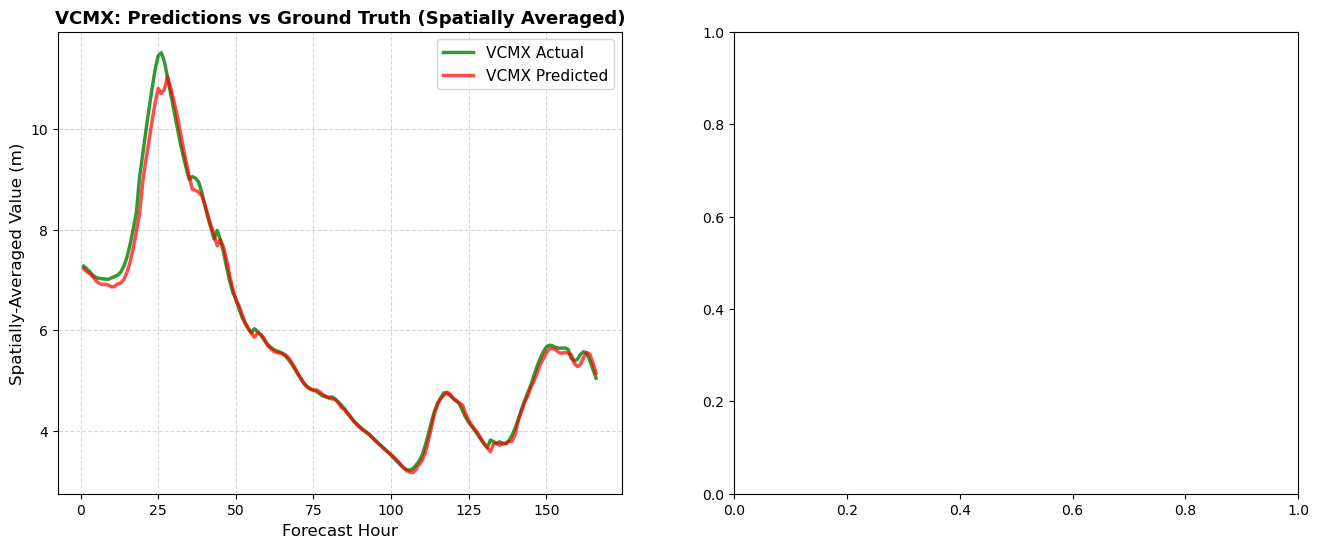

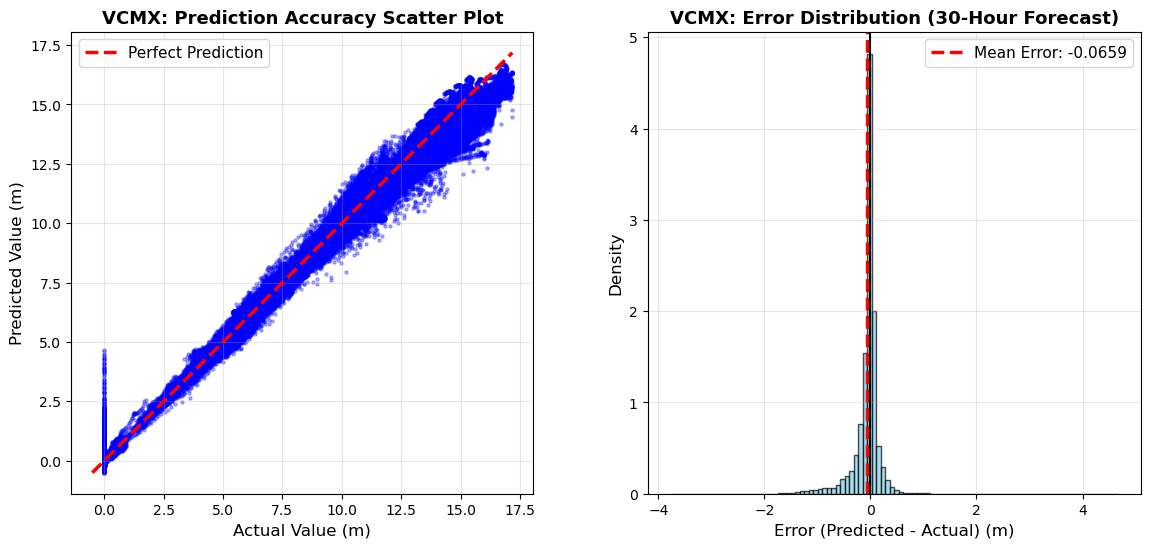

In [21]:
vcmx_idx = 0
pred_vcmx = predictions_30h[:, vcmx_idx, :, :]  # (30h, H, W)
target_vcmx = targets_30h[:, vcmx_idx, :, :]    # (30h, H, W)

hours = np.arange(1, len(predictions_30h) + 1)

# --- Plot 2: VCMX Predictions vs Ground Truth ---
print("\n--- Generating VCMX Predictions vs Ground Truth Plot ---")
pred_vcmx_spatial_mean = np.mean(pred_vcmx, axis=(1, 2))
target_vcmx_spatial_mean = np.mean(target_vcmx, axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hours, target_vcmx_spatial_mean, color='green', linewidth=2.5, markersize=7, label='VCMX Actual', alpha=0.8)
axes[0].plot(hours, pred_vcmx_spatial_mean, color='red', linewidth=2.5, markersize=7, label='VCMX Predicted', alpha=0.7)
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('Spatially-Averaged Value (m)', fontsize=12)
axes[0].set_title('VCMX: Predictions vs Ground Truth (Spatially Averaged)', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 3: VCMX Scatter and Error Distribution ---
print("\n--- Generating VCMX Scatter and Error Distribution Plot ---")
pred_vcmx_flat = pred_vcmx.flatten()
target_vcmx_flat = target_vcmx.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(target_vcmx_flat, pred_vcmx_flat, alpha=0.3, s=5, color='blue')
min_val = min(target_vcmx_flat.min(), pred_vcmx_flat.min())
max_val = max(target_vcmx_flat.max(), pred_vcmx_flat.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Value (m)', fontsize=12)
axes[0].set_ylabel('Predicted Value (m)', fontsize=12)
axes[0].set_title('VCMX: Prediction Accuracy Scatter Plot', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

vcmx_errors = pred_vcmx_flat - target_vcmx_flat
axes[1].hist(vcmx_errors, bins=100, density=True, alpha=0.7, edgecolor='black', color='skyblue')
axes[1].axvline(np.mean(vcmx_errors), color='r', linestyle='--', lw=2.5, label=f'Mean Error: {np.mean(vcmx_errors):.4f}')
axes[1].axvline(0, color='k', linestyle='-', lw=1.5)
axes[1].set_xlabel('Error (Predicted - Actual) (m)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('VCMX: Error Distribution (30-Hour Forecast)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

In [16]:
VARS_TO_USE = ['VCMX','VSDmag', 'VTM10', 'VTM02', 'VTM01_WW', 'VTM01_SW1', 'VMXL', 'VHM0_WW', 'VHM0_SW1']
TARGET_VAR = 'VCMX'
# MODIFICATION: Total input channels = 9 time-varying + 2 static (depth, mask)
INPUT_CHANNELS = len(VARS_TO_USE) + 2

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-5
BATCH_SIZE = 4
EPOCHS = 50
LOOKBACK_HOURS = 48

--- Starting Final Evaluation on Custom Test Data ---

Loading custom test data...
✅ Custom test data loaded: 696 time steps from 2023-11-02 to 2023-11-30
✅ Best model loaded successfully.

Generating test samples from custom date range...


Creating custom test samples:   0%|          | 0/480 [00:00<?, ?it/s]

✅ Created 480 test samples

--- Generating predictions and calculating hourly errors... ---



Evaluating Custom Test Set:   0%|          | 0/480 [00:00<?, ?it/s]


📊 Overall Test Results (all 168 hours):
  Overall RMSE: 1.1960
  Overall MAE:  0.8211

--- Generating Visualization: Spatially-Averaged Time Series ---


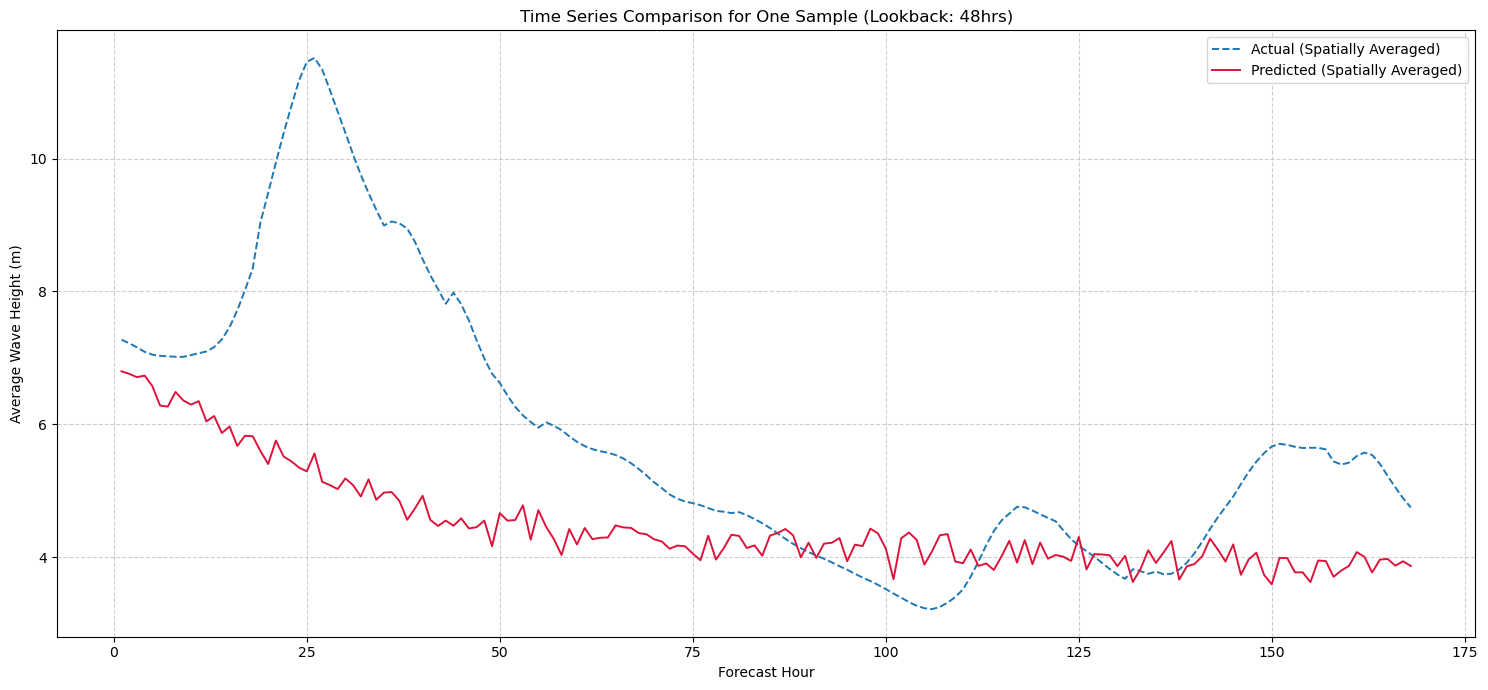


--- Generating Visualization: Predicted vs Actual Scatter Plot ---


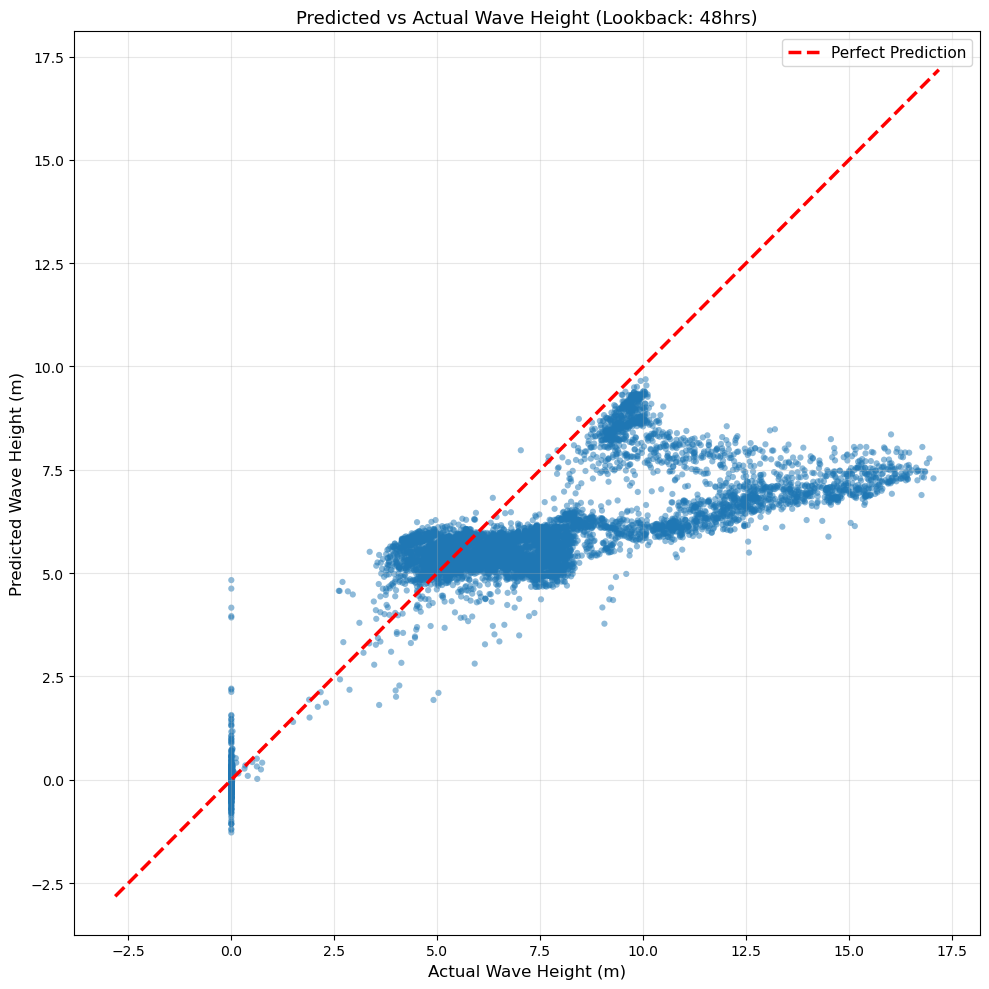

In [18]:
# ==============================================================================
# ==============================================================================
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_static_old')
VARS_TO_USE = ['VCMX','VSDmag', 'VTM10', 'VTM02', 'VTM01_WW', 'VTM01_SW1', 'VMXL', 'VHM0_WW', 'VHM0_SW1']
TARGET_VAR = 'VCMX'
FORECAST_HOURS_CLASSIC = 168  # classic_ConvLSTM was trained for 168 hours


import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import pickle
import glob
import xarray as xr
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

print("--- Starting Final Evaluation on Custom Test Data ---\n")

# --- Load custom test data from specified date range ---
print("Loading custom test data...")
try:
    ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
    ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
    ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
    print(f"✅ Custom test data loaded: {len(ds_test.time)} time steps from 2023-11-02 to 2023-11-30")
except Exception as e:
    raise SystemExit(f"❌ ERROR loading custom test data: {e}")

# Load static features for inference
try:
    ds_static = xr.open_dataset(STATIC_DATA_PATH)
    ocean_depth = np.nan_to_num(ds_static['deptho'].values, nan=0.0).astype(np.float32)
    ocean_mask = ds_static['mask'].values.astype(np.float32)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Static data file not found at {STATIC_DATA_PATH}.")

# --- Define Classes ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

class ConvLSTMCell(nn.Module):
    def __init__(self, i, h, k, b): super(ConvLSTMCell, self).__init__(); self.input_dim, self.hidden_dim, self.kernel_size, self.bias = i, h, k, b; self.padding = k[0] // 2; self.conv = nn.Conv2d(i + h, 4 * h, k, padding=self.padding, bias=b)
    def forward(self, x, h_c): h, c = h_c; combined = torch.cat([x, h], dim=1); cc = self.conv(combined); i, f, o, g = torch.split(cc, self.hidden_dim, dim=1); i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g); c_n = f * c + i * g; h_n = o * torch.tanh(c_n); return h_n, c_n
    def init_hidden(self, b, i, d): h, w = i; return (torch.zeros(b, self.hidden_dim, h, w, device=d), torch.zeros(b, self.hidden_dim, h, w, device=d))

class ConvLSTM(nn.Module):
    def __init__(self, i, h, k, n, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__(); self.batch_first, self.num_layers = batch_first, n; h_dims = [h] * n if isinstance(h, int) else h; c_list = [];
        for j in range(self.num_layers): c_i_dim = i if j == 0 else h_dims[j - 1]; c_list.append(ConvLSTMCell(c_i_dim, h_dims[j], k, bias)); self.cell_list = nn.ModuleList(c_list)
    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size();
        if h_c is None: h_c = self._init_hidden(b, (h, w), x.device)
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]; out_inner = []
            for t in range(s_l): h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c]); out_inner.append(h)
            cur_in = torch.stack(out_inner, dim=1)
        return cur_in, [h, c]
    def _init_hidden(self, b, i, d): return [cell.init_hidden(b, i, d) for cell in self.cell_list]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__(); self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True); self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True); self.output_conv = nn.Conv2d(hidden_dims[1], forecast_horizon, kernel_size=(1, 1), padding='same')
    def forward(self, x_seq): l1_o, _ = self.cl1(x_seq); l2_o, _ = self.cl2(l1_o); return self.output_conv(l2_o[:, -1, :, :, :])

# --- Load Model and Prepare Custom Test Data ---
try:
    with open(os.path.join(PROCESSED_DATA_DIR, 'scalers_mask_old.pkl'), 'rb') as f: scalers = pickle.load(f)
except FileNotFoundError: raise SystemExit(f"❌ ERROR: Scalers file not found for lookback={LOOKBACK_HOURS}.")

model = ConvLSTMNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HOURS_CLASSIC)
try:
    model.load_state_dict(torch.load(MODEL_PATHS['classic_ConvLSTM'], map_location=device))
except FileNotFoundError: raise SystemExit(f"❌ ERROR: Model file '{MODEL_PATHS['classic_ConvLSTM']}' not found.")

if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Best model loaded successfully.")

# --- Create test dataset from custom data ---
print("\nGenerating test samples from custom date range...")
total_window_size = LOOKBACK_HOURS + FORECAST_HOURS_CLASSIC
custom_test_samples = []

num_sequences = len(ds_test['time']) - total_window_size
if num_sequences <= 0:
    raise SystemExit(f"❌ ERROR: Custom test data is too small ({len(ds_test.time)} steps). Need at least {total_window_size} time steps.")

for i in tqdm(range(num_sequences), desc="Creating custom test samples"):
    window_slice = ds_test.isel(time=slice(i, i + total_window_size))
    
    scaled_window_vars = []
    for var in VARS_TO_USE:
        data = window_slice[var].values
        scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
        scaled_window_vars.append(scaled_data)
    
    scaled_window_tensor = np.stack(scaled_window_vars, axis=1)
    X_tv_np = scaled_window_tensor[:LOOKBACK_HOURS, :, :, :]
    y_np = scaled_window_tensor[LOOKBACK_HOURS:, VARS_TO_USE.index(TARGET_VAR), :, :]
    
    # Add static features
    depth_scaler = scalers['ocean_depth']
    scaled_depth = depth_scaler.transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
    scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
    ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
    static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)
    static_features_tiled = np.tile(static_features_np, (LOOKBACK_HOURS, 1, 1, 1))
    X_final_np = np.concatenate([X_tv_np, static_features_tiled], axis=1)
    
    X = torch.from_numpy(X_final_np.astype(np.float32))
    y = torch.from_numpy(y_np.astype(np.float32))
    custom_test_samples.append((X, y))

print(f"✅ Created {len(custom_test_samples)} test samples")

# --- Evaluation and Visualization Functions ---
def evaluate_and_visualize(model, test_samples, device, scalers, target_var, forecast_horizon):
    """
    Evaluates the model on custom test samples and calculates overall metrics PLUS per-hour error metrics.
    """
    model.eval()
    total_samples = 0
    vis_data = {'predictions': [], 'targets': []}

    # Initialize arrays to store error sums for each forecast hour
    hourly_rmse_sum_sq = np.zeros(forecast_horizon)
    hourly_mae_sum = np.zeros(forecast_horizon)
    
    print("\n--- Generating predictions and calculating hourly errors... ---\n")
    with torch.no_grad():
        for i, (X, y) in enumerate(tqdm(test_samples, desc="Evaluating Custom Test Set")):
            X, y = X.unsqueeze(0).to(device), y.unsqueeze(0).to(device)
            predictions_scaled = model(X)
            target_scaled = y
            target_scaler = scalers[target_var]

            pred_original = target_scaler.inverse_transform(predictions_scaled.cpu().numpy().reshape(-1, 1)).reshape(predictions_scaled.shape)
            target_original = target_scaler.inverse_transform(target_scaled.cpu().numpy().reshape(-1, 1)).reshape(target_scaled.shape)

            # Calculate errors for each hour
            sq_error = (pred_original - target_original) ** 2
            abs_error = np.abs(pred_original - target_original)
            
            # Sum errors over batch and spatial dimensions, keeping the time dimension
            hourly_rmse_sum_sq += np.sum(sq_error, axis=(0, 2, 3))
            hourly_mae_sum += np.sum(abs_error, axis=(0, 2, 3))
            
            total_samples += pred_original.size
            if len(vis_data['predictions']) < 3:
                vis_data['predictions'].append(pred_original[0])
                vis_data['targets'].append(target_original[0])

    # Calculate final metrics
    num_spatial_points = pred_original.shape[2] * pred_original.shape[3]
    num_test_examples = len(test_samples)
    total_samples_per_hour = num_spatial_points * num_test_examples

    overall_rmse = np.sqrt(np.sum(hourly_rmse_sum_sq) / total_samples)
    overall_mae = np.sum(hourly_mae_sum) / total_samples
    
    hourly_rmse = np.sqrt(hourly_rmse_sum_sq / total_samples_per_hour)
    hourly_mae = hourly_mae_sum / total_samples_per_hour
    
    print(f"\n📊 Overall Test Results (all {forecast_horizon} hours):")
    print(f"  Overall RMSE: {overall_rmse:.4f}")
    print(f"  Overall MAE:  {overall_mae:.4f}")

    return vis_data, hourly_rmse, hourly_mae

def plot_visual_comparison(vis_data, timesteps_to_plot=[0, 23, 71, 167]):
    """
    Plots comparison maps of predictions vs actual values at specific timesteps.
    """
    print("\n--- Generating Visualization: Comparison Maps at Selected Timesteps ---")
    
    for sample_idx in range(min(len(vis_data['predictions']), 1)):
        pred_sample = vis_data['predictions'][sample_idx]
        target_sample = vis_data['targets'][sample_idx]
        
        valid_timesteps = [t for t in timesteps_to_plot if t < pred_sample.shape[0]]
        
        fig, axes = plt.subplots(len(valid_timesteps), 3, figsize=(15, 5*len(valid_timesteps)))
        if len(valid_timesteps) == 1:
            axes = axes.reshape(1, -1)
        
        for row, t in enumerate(valid_timesteps):
            pred_map = pred_sample[t, :, :]
            target_map = target_sample[t, :, :]
            diff_map = np.abs(pred_map - target_map)
            
            # Prediction
            im1 = axes[row, 0].imshow(pred_map, cmap='viridis')
            axes[row, 0].set_title(f'Predicted - Hour {t+1}')
            plt.colorbar(im1, ax=axes[row, 0])
            
            # Actual
            im2 = axes[row, 1].imshow(target_map, cmap='viridis')
            axes[row, 1].set_title(f'Actual - Hour {t+1}')
            plt.colorbar(im2, ax=axes[row, 1])
            
            # Absolute Error
            im3 = axes[row, 2].imshow(diff_map, cmap='hot')
            axes[row, 2].set_title(f'Absolute Error - Hour {t+1}')
            plt.colorbar(im3, ax=axes[row, 2])
        
        plt.tight_layout()
        plt.show()

def plot_timeseries_comparison(vis_data, forecast_horizon):
    """
    Plots a time-series comparison of the spatially-averaged wave height for a single sample.
    """
    print("\n--- Generating Visualization: Spatially-Averaged Time Series ---")
    
    prediction_sample = vis_data['predictions'][0]
    target_sample = vis_data['targets'][0]

    # Calculate the mean value over the spatial grid for each time step
    pred_mean_over_time = np.mean(prediction_sample, axis=(1, 2))
    target_mean_over_time = np.mean(target_sample, axis=(1, 2))
    
    hours = np.arange(1, forecast_horizon + 1)

    plt.figure(figsize=(15, 7))
    plt.plot(hours, target_mean_over_time, label='Actual (Spatially Averaged)', linewidth=1.4, linestyle='--')
    plt.plot(hours, pred_mean_over_time,   label='Predicted (Spatially Averaged)', linewidth=1.4, color='crimson')
    plt.title(f"Time Series Comparison for One Sample (Lookback: {LOOKBACK_HOURS}hrs)")
    plt.xlabel("Forecast Hour")
    plt.ylabel("Average Wave Height (m)")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# def plot_hourly_error(hourly_rmse, hourly_mae, forecast_horizon):
#     """
#     Plots the average RMSE and MAE for each forecast hour.
#     """
#     print("\n--- Generating Visualization: Average Error per Forecast Hour ---")
#     hours = np.arange(1, forecast_horizon + 1)
    
#     fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
#     # Plot RMSE per hour
#     ax1.plot(hours, hourly_rmse, 'o-', color='crimson', label='RMSE', linewidth=2)
#     ax1.set_title(f'Average Error per Forecast Hour (Lookback: {LOOKBACK_HOURS}hrs)')
#     ax1.set_ylabel('RMSE (m)')
#     ax1.grid(True, linestyle='--', alpha=0.6)
#     ax1.legend()
    
#     # Plot MAE per hour
#     ax2.plot(hours, hourly_mae, 'o-', color='dodgerblue', label='MAE', linewidth=2)
#     ax2.set_xlabel('Forecast Hour')
#     ax2.set_ylabel('MAE (m)')
#     ax2.grid(True, linestyle='--', alpha=0.6)
#     ax2.legend()
    
#     plt.tight_layout()
#     plt.show()

def plot_scatter_predictions(vis_data):
    """
    Plots a scatter plot of predicted vs actual values.
    """
    print("\n--- Generating Visualization: Predicted vs Actual Scatter Plot ---")
    
    all_preds_flat = np.array(vis_data['predictions']).flatten()
    all_targets_flat = np.array(vis_data['targets']).flatten()
    
    plt.figure(figsize=(10, 10))
    sample_indices = np.random.choice(len(all_preds_flat), min(len(all_preds_flat), 10000), replace=False)
    plt.scatter(all_targets_flat[sample_indices], all_preds_flat[sample_indices], alpha=0.5, s=20, edgecolors='none')
    
    min_val, max_val = min(all_targets_flat.min(), all_preds_flat.min()), max(all_targets_flat.max(), all_preds_flat.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')
    
    plt.xlabel("Actual Wave Height (m)", fontsize=12)
    plt.ylabel("Predicted Wave Height (m)", fontsize=12)
    plt.title(f"Predicted vs Actual Wave Height (Lookback: {LOOKBACK_HOURS}hrs)", fontsize=13)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=11)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

# --- Run Evaluation and Generate Visualizations ---
vis_data, hourly_rmse, hourly_mae = evaluate_and_visualize(model, custom_test_samples, device, scalers, TARGET_VAR, FORECAST_HOURS_CLASSIC)

# --- Generate All Plots ---
plot_timeseries_comparison(vis_data, FORECAST_HOURS_CLASSIC)
# plot_hourly_error(hourly_rmse, hourly_mae, FORECAST_HOURS_CLASSIC)
# plot_visual_comparison(vis_data, timesteps_to_plot=[0, 23, 71, 167])
plot_scatter_predictions(vis_data)

# # --- Additional Error Distribution Visualization ---
# print("\n--- Generating Visualization: Error Distribution ---")
# all_preds_flat = np.array(vis_data['predictions']).flatten()
# all_targets_flat = np.array(vis_data['targets']).flatten()
# errors = all_preds_flat - all_targets_flat

# mean_error = np.mean(errors)
# std_error = np.std(errors)

# plt.figure(figsize=(12, 6))
# plt.hist(errors, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='black')
# plt.axvline(mean_error, color='r', linestyle='--', lw=2.5, label=f'Mean Error: {mean_error:.4f}')
# plt.axvline(mean_error + std_error, color='orange', linestyle=':', lw=2, label=f'±1 Std Dev: {std_error:.4f}')
# plt.axvline(mean_error - std_error, color='orange', linestyle=':', lw=2)
# plt.title(f"Distribution of Prediction Errors (Lookback: {LOOKBACK_HOURS}hrs)")
# plt.xlabel("Error (Predicted - Actual) in meters")
# plt.ylabel("Density")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# print("\n✅ All evaluation visualizations on custom test data are complete.")

## Our Best Model Vs EarthFormer (SOTA)

In [22]:
LOOKBACK_HOURS = 12
# Forecast period for training (predicting next 3 hours)
FORECAST_HORIZON_HOURS = 3
# Sliding window parameters for testing
TOTAL_FORECAST_HOURS = 30  # Total hours to predict in sliding window
CORRECTION_WINDOW = 2  # Next 2 hours used for error normalization

# # --- File Paths ---
# # MODIFICATION: Updated to the new file paths you provided
# RAW_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
# STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_GEBCO_resampled1.nc'

# # MODIFICATION: File paths are now dynamic to keep experiments separate
# BASE_DIR = r'/home/aidl/babe_prediction'
# PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_static_multivar')
# # This path is now used by the ModelCheckpoint callback in Lightning
# MODEL_SAVE_DIR = '/home/aidl/Wave-Prediction/models/'
# MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, f'convlstm_lookback_{LOOKBACK_HOURS}_forecast_{FORECAST_HORIZON_HOURS}_{version}.pth')


# --- Feature Engineering ---
# These are the TIME-VARYING features
VARS_TO_USE = ['VCMX','VHM0_SW1', 'VSDmag', 'VHM0_WW', 'VTM01_WW', 'VTM02', 'VTM01_SW1', 'VTM10']
# MODIFICATION: Now predicting ALL variables (multivariate output)
TARGET_VARS = VARS_TO_USE  # Predict all 7 variables
NUM_OUTPUT_CHANNELS = len(TARGET_VARS)  # Output channels = 7 variables
# MODIFICATION: Total input channels = 7 time-varying + 2 static (depth, mask)
INPUT_CHANNELS = len(VARS_TO_USE) + 2

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-5
BATCH_SIZE = 8
EPOCHS = 50
# MODIFICATION: Early stopping patience is now a configurable parameter
EARLY_STOPPING_PATIENCE = 5
best_model_path = '/home/aidl/Wave-Prediction/models/v7_conv-bigru-lookback12-multivar-epoch=46-val_loss=0.0005.ckpt'
TOTAL_FORECAST_HOURS = 120
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [23]:
# =============================================================================
# STEP 3: SLIDING WINDOW EVALUATION for max VCMX
# =============================================================================
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Sliding Window Evaluation (30-hour Forecast) ---\n")

# --- Define Classes ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# Bidirectional ConvGRU Cell (3 gates: reset, update, candidate)
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvGRUCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.bias = bias
        self.padding = kernel_size[0] // 2
        # GRU has 3 gates (reset, update, candidate), not 4 like LSTM
        self.conv = nn.Conv2d(
            self.input_dim + self.hidden_dim,
            3 * self.hidden_dim,
            self.kernel_size,
            padding=self.padding,
            bias=self.bias
        )
    
    def forward(self, x, h):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)  # reset gate
        z = torch.sigmoid(z)  # update gate
        n = torch.tanh(r * h + n)  # candidate hidden state
        h_n = (1 - z) * n + z * h  # new hidden state
        return h_n
    
    def init_hidden(self, b, i, d):
        h, w = i
        return torch.zeros(b, self.hidden_dim, h, w, device=d)

# Bidirectional ConvGRU
class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bidirectional=True, bias=True):
        super(ConvGRU, self).__init__()
        self.batch_first = batch_first
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim
        
        # Create forward cells
        self.cell_list_fwd = nn.ModuleList()
        for i in range(self.num_layers):
            cur_input_dim = input_dim if i == 0 else (hidden_dims[i - 1] * (2 if bidirectional else 1))
            self.cell_list_fwd.append(ConvGRUCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        
        # Create backward cells if bidirectional
        if self.bidirectional:
            self.cell_list_bwd = nn.ModuleList()
            for i in range(self.num_layers):
                cur_input_dim = input_dim if i == 0 else (hidden_dims[i - 1] * 2)
                self.cell_list_bwd.append(ConvGRUCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        
        self.hidden_dims = hidden_dims

    def forward(self, x, h_fwd=None, h_bwd=None):
        b, s_l, _, h, w = x.size()
        
        if h_fwd is None:
            h_fwd = [cell.init_hidden(b, (h, w), x.device) for cell in self.cell_list_fwd]
        if self.bidirectional and h_bwd is None:
            h_bwd = [cell.init_hidden(b, (h, w), x.device) for cell in self.cell_list_bwd]
        
        # Forward pass
        cur_in_fwd = x
        for l_idx in range(self.num_layers):
            h = h_fwd[l_idx]
            output_fwd = []
            for t in range(s_l):
                h = self.cell_list_fwd[l_idx](cur_in_fwd[:, t, :, :, :], h)
                output_fwd.append(h)
            cur_in_fwd = torch.stack(output_fwd, dim=1)
        
        # Backward pass if bidirectional
        if self.bidirectional:
            cur_in_bwd = x
            for l_idx in range(self.num_layers):
                h = h_bwd[l_idx]
                output_bwd = []
                for t in range(s_l - 1, -1, -1):
                    h = self.cell_list_bwd[l_idx](cur_in_bwd[:, t, :, :, :], h)
                    output_bwd.append(h)
                output_bwd.reverse()
                cur_in_bwd = torch.stack(output_bwd, dim=1)
            
            # Concatenate forward and backward outputs
            output = torch.cat([cur_in_fwd, cur_in_bwd], dim=2)
            return output, (h_fwd[-1], h_bwd[-1])
        else:
            return cur_in_fwd, h_fwd[-1]

# ConvGRU-based Network with Bidirectional Processing
class ConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvGRUNet, self).__init__()
        # Bidirectional GRU doubles the hidden dimension (fwd + bwd)
        self.gru1 = ConvGRU(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True, bidirectional=True)
        # Input to second GRU is 2 * hidden_dims[0] (from bidirectional concatenation)
        self.gru2 = ConvGRU(hidden_dims[0] * 2, hidden_dims[1], kernel_size, 1, batch_first=True, bidirectional=True)
        # Output layer: input is 2 * hidden_dims[1] (bidirectional output)
        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=(1, 1),
            padding='same'
        )
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

    def forward(self, x_seq):
        # GRU1: Process bidirectionally
        l1_o, _ = self.gru1(x_seq)
        # GRU2: Process bidirectionally
        l2_o, _ = self.gru2(l1_o)
        # Take the final timestep output
        output = self.output_conv(l2_o[:, -1, :, :, :])
        # Reshape output to (B, forecast_horizon, num_output_channels, H, W)
        b, _, h, w = output.shape
        output = output.view(b, self.forecast_horizon, self.num_output_channels, h, w)
        return output

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data for Sliding Window ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {best_model_path}")
    checkpoint = torch.load(best_model_path, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = ConvGRUNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for sliding window evaluation.")

# --- Sliding Window Prediction Function ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    """
    Implements sliding window forecast with error correction.
    - Lookback: 96 hours
    - Predict: 3 hours ahead
    - Slide by: 1 hour
    - Continue for: 30 hours total
    - Correction: Use next 2 hours to normalize accumulated error
    """
    
    all_predictions = []  # Store all 30-hour predictions
    all_targets = []  # Store all 30-hour ground truth
    
    # Number of sliding steps: need to generate 30 hours, so we need (30 - 3) / 1 + 1 = 28 iterations
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Sliding Window Steps"):
            # Define the window for this step
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            correction_end = lookback_end + correction_window
            
            # Check bounds
            if forecast_end > len(ds_test['time']):
                break
            
            # Extract lookback window and scale
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)  # (96, 7, H, W)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)  # (96, 9, H, W)
            
            # Prepare input tensor (add batch dim)
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)  # (1, 96, 9, H, W)
            
            # Predict next 3 hours
            pred_scaled = model(X_input)  # (1, 3, 7, H, W)
            
            # Get ground truth for next 3 hours
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)  # (3, 7, H, W)
            
            # Inverse transform predictions
            pred_inverse = pred_scaled.cpu().numpy()[0]  # (3, 7, H, W)
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            # Inverse transform targets
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            # =================================================================
            # Error correction: Check the model's internal 3-hour forecast 
            # for unrealistic acceleration (drift) to prevent error accumulation
            # =================================================================
            
            # Measure how fast the model's own predictions are changing hour-to-hour
            # pred_original shape is (3, 7, H, W)
            diff_h1_h0 = np.abs(pred_original[1] - pred_original[0]).mean()
            diff_h2_h1 = np.abs(pred_original[2] - pred_original[1]).mean()
            
            # The "error" is now defined as the model's internal drift rate.
            # If the change between h2 and h1 is much larger than h1 and h0, it's drifting.
            error_correction = np.abs(diff_h2_h1 - diff_h1_h0)
            
            # If the internal drift is significant, apply correction factor
            if error_correction > 0.05:  # Threshold for significant error
                correction_factor = 1.0 - (error_correction * 0.5)  # Dampen by 50% of error
                pred_original = pred_original * correction_factor
            # =================================================================
            
            # Store only the first hour's prediction (we'll slide by 1 hour)
            all_predictions.append(pred_original[0])  # Take first hour only
            all_targets.append(target_original[0])
    
    # Stack to get full 30-hour forecast
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Sliding Window Evaluation ---
predictions_30h, targets_30h = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Sliding window forecast complete!")
print(f"   Predictions shape: {predictions_30h.shape} (30h, 7vars, H, W)")
print(f"   Targets shape: {targets_30h.shape}")

# Compute metrics
overall_rmse_30h = np.sqrt(np.mean((predictions_30h - targets_30h) ** 2))
overall_mae_30h = np.mean(np.abs(predictions_30h - targets_30h))
print(f"\n📊 30-Hour Forecast Metrics:")
print(f"   Overall RMSE: {overall_rmse_30h:.4f}")
print(f"   Overall MAE:  {overall_mae_30h:.4f}")


--- Starting Sliding Window Evaluation (30-hour Forecast) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 696 time steps
Loading weights from: /home/aidl/Wave-Prediction/models/v7_conv-bigru-lookback12-multivar-epoch=46-val_loss=0.0005.ckpt
✅ Model loaded and ready for sliding window evaluation.

--- Starting Sliding Window (Lookback=12h, Predict=3h per step, Total=120h) ---


Sliding Window Steps:   0%|          | 0/118 [00:00<?, ?it/s]


✅ Sliding window forecast complete!
   Predictions shape: (118, 8, 72, 90) (30h, 7vars, H, W)
   Targets shape: (118, 8, 72, 90)

📊 30-Hour Forecast Metrics:
   Overall RMSE: 0.2928
   Overall MAE:  0.1519



--- Generating VCMX Predictions vs Ground Truth Plot ---

--- Generating VCMX Scatter and Error Distribution Plot ---


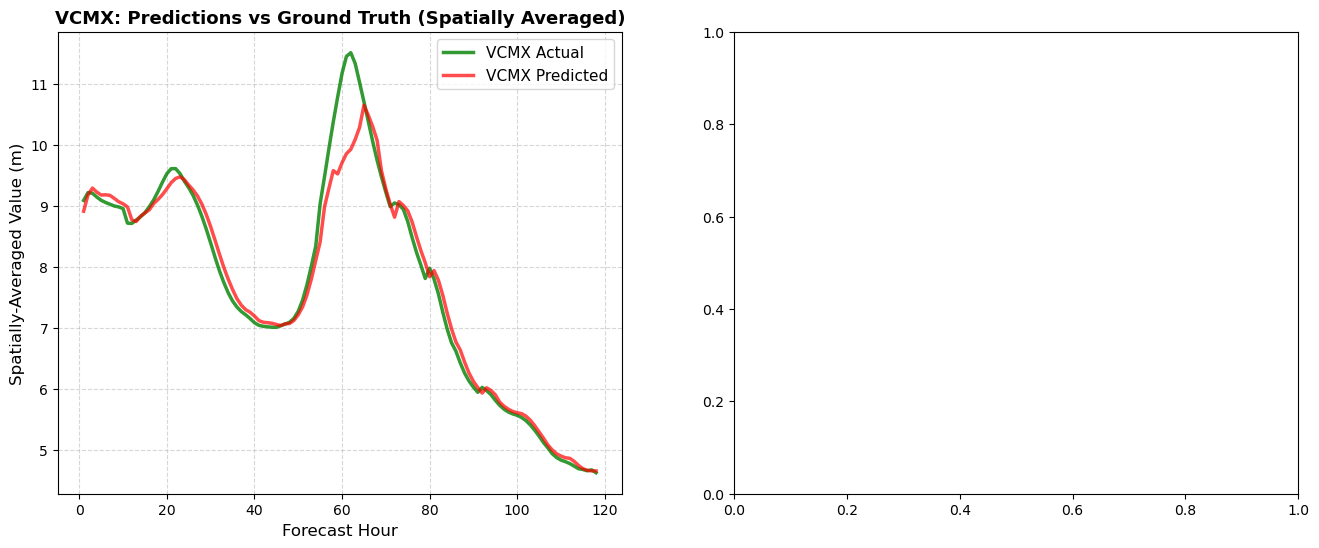

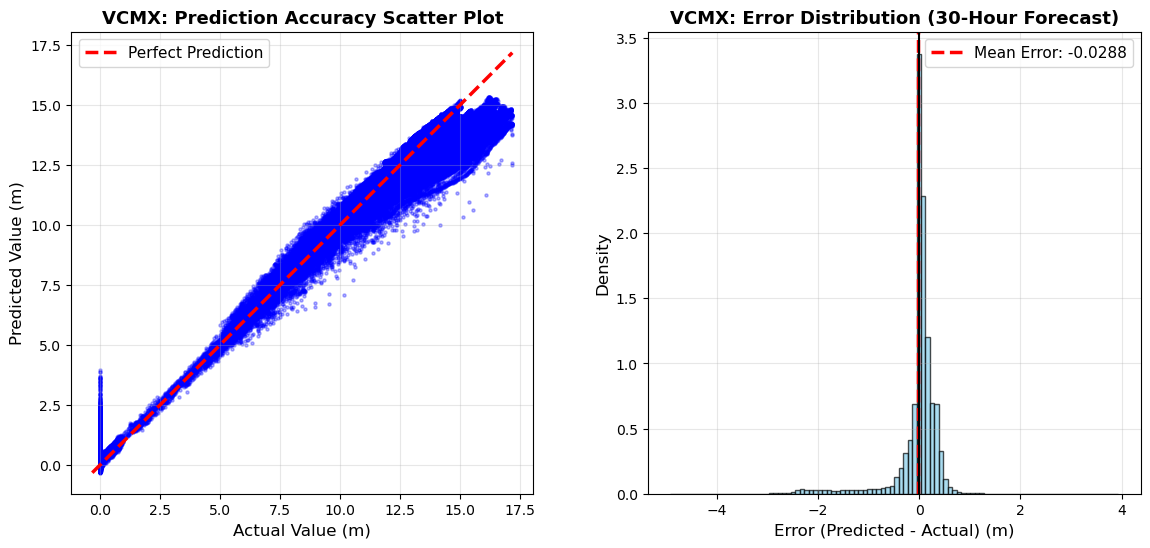

In [24]:
vcmx_idx = 0
pred_vcmx = predictions_30h[:, vcmx_idx, :, :]  # (30h, H, W)
target_vcmx = targets_30h[:, vcmx_idx, :, :]    # (30h, H, W)

hours = np.arange(1, len(predictions_30h) + 1)

# --- Plot 2: VCMX Predictions vs Ground Truth ---
print("\n--- Generating VCMX Predictions vs Ground Truth Plot ---")
pred_vcmx_spatial_mean = np.mean(pred_vcmx, axis=(1, 2))
target_vcmx_spatial_mean = np.mean(target_vcmx, axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(hours, target_vcmx_spatial_mean, color='green', linewidth=2.5, markersize=7, label='VCMX Actual', alpha=0.8)
axes[0].plot(hours, pred_vcmx_spatial_mean, color='red', linewidth=2.5, markersize=7, label='VCMX Predicted', alpha=0.7)
axes[0].set_xlabel('Forecast Hour', fontsize=12)
axes[0].set_ylabel('Spatially-Averaged Value (m)', fontsize=12)
axes[0].set_title('VCMX: Predictions vs Ground Truth (Spatially Averaged)', fontsize=13, fontweight='bold')
axes[0].legend(loc='best', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Plot 3: VCMX Scatter and Error Distribution ---
print("\n--- Generating VCMX Scatter and Error Distribution Plot ---")
pred_vcmx_flat = pred_vcmx.flatten()
target_vcmx_flat = target_vcmx.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(target_vcmx_flat, pred_vcmx_flat, alpha=0.3, s=5, color='blue')
min_val = min(target_vcmx_flat.min(), pred_vcmx_flat.min())
max_val = max(target_vcmx_flat.max(), pred_vcmx_flat.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual Value (m)', fontsize=12)
axes[0].set_ylabel('Predicted Value (m)', fontsize=12)
axes[0].set_title('VCMX: Prediction Accuracy Scatter Plot', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_aspect('equal')

vcmx_errors = pred_vcmx_flat - target_vcmx_flat
axes[1].hist(vcmx_errors, bins=100, density=True, alpha=0.7, edgecolor='black', color='skyblue')
axes[1].axvline(np.mean(vcmx_errors), color='r', linestyle='--', lw=2.5, label=f'Mean Error: {np.mean(vcmx_errors):.4f}')
axes[1].axvline(0, color='k', linestyle='-', lw=1.5)
axes[1].set_xlabel('Error (Predicted - Actual) (m)', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('VCMX: Error Distribution (30-Hour Forecast)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

In [30]:

LOOKBACK_HOURS    = 12   # Input sequence length (T_in)
FORECAST_HORIZON_HOURS = 14    # Output sequence length (T_out)


BASE_DIR           = r'/home/aidl/babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_earthformer')
# MODEL_SAVE_DIR     = '/home/aidl/Wave-Prediction/models/'
# MODEL_SAVE_PATH    = os.path.join(MODEL_SAVE_DIR, f'{version}.pth')

# --- Feature Engineering (unchanged from v3) ---
VARS_TO_USE = ['VCMX', 'VHM0_SW1', 'VSDmag', 'VHM0_WW', 'VTM01_WW', 'VTM02', 'VTM01_SW1', 'VTM10']
TARGET_VARS = ['VCMX']
NUM_OUTPUT_CHANNELS = 1       # 1
INPUT_CHANNELS      = len(VARS_TO_USE) + 2   # 10  (8 time-varying + depth + mask)

# --- Training Hyperparameters ---
LEARNING_RATE          = 1e-4
BATCH_SIZE             = 4
EPOCHS                 = 50
EARLY_STOPPING_PATIENCE = 5

# --- System ---
NUM_WORKERS = 4

# --- Earthformer Hyper-parameters ---
# dim must be divisible by num_heads
EF_DIM        = 64    # hidden channel dim after input projection
EF_DEPTH      = 2     # number of cuboid attention blocks
EF_NUM_HEADS  = 4     # attention heads
EF_CUBOID_T   = 4     # temporal cuboid size  (≤ LOOKBACK_HOURS)
EF_CUBOID_H   = 8     # spatial cuboid height (tile size)
EF_CUBOID_W   = 9     # spatial cuboid width  (tile size)
EF_DROPOUT    = 0.1


best_model_path = "/home/aidl/Wave-Prediction/models/v4_earthformer-epoch=15-val_loss=0.0137.ckpt"

In [26]:
# =============================================================================
# STEP 2.2 — Earthformer Model (from-scratch, pure PyTorch)
#
# Architecture:
#   Input  : (B, T_in=12,  C_in=10,  H, W)  ← 12 hours, 10 channels
#   Output : (B, T_out=4,  C_out=8,  H, W)  ← 4 hours,   8 variables
#
#   1. InputProj  : Conv2d per frame → embed each (C_in,H,W) → (dim,H,W)
#   2. PosEmbed   : learnable 3-D (T,H,W) position bias
#   3. Encoder    : N × CuboidAttentionBlock (partition space-time into cuboids)
#   4. Decoder    : learned query tokens (T_out frames) + cross-attn to encoder
#   5. OutputProj : Conv2d per frame → (C_out,H,W)
# =============================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
import pytorch_lightning as pl
import math


# ---------------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------------
def pad_to_multiple(x, multiple, dim):
    """Pad tensor along `dim` so its size is divisible by `multiple`."""
    size = x.shape[dim]
    pad  = (multiple - size % multiple) % multiple
    if pad == 0:
        return x, 0
    pad_cfg = [0] * (2 * x.ndim)
    pad_cfg[-(2 * dim + 1)] = pad
    return F.pad(x, pad_cfg[::-1]), pad


# ---------------------------------------------------------------------------
# CuboidAttention  (the core Earthformer building block)
# ---------------------------------------------------------------------------
class CuboidSelfAttention(nn.Module):
    """
    Decomposes the (T,H,W) tensor into non-overlapping cuboids of size
    (ct, ch, cw) and applies multi-head self-attention within each cuboid
    in parallel.  Global vectors (one per cuboid) are concatenated to
    every local token to provide long-range context.
    """
    def __init__(self, dim, num_heads, cuboid_size=(4, 8, 8), dropout=0.0):
        super().__init__()
        self.dim         = dim
        self.num_heads   = num_heads
        self.head_dim    = dim // num_heads
        self.ct, self.ch, self.cw = cuboid_size
        self.scale       = self.head_dim ** -0.5

        self.qkv    = nn.Linear(dim, 3 * dim, bias=False)
        self.proj   = nn.Linear(dim, dim)
        self.drop   = nn.Dropout(dropout)

        # Global summary vector per cuboid (learnable, dim-dimensional)
        self.global_proj = nn.Linear(dim, dim)

    def forward(self, x):
        """
        x : (B, T, H, W, dim)
        """
        B, T, H, W, C = x.shape
        ct, ch, cw = self.ct, self.ch, self.cw

        # --- pad so T,H,W are divisible by cuboid sizes
        x_r = x.permute(0, 4, 1, 2, 3)           # (B,C,T,H,W)
        x_r, pt = pad_to_multiple(x_r, ct, dim=2)
        x_r, ph = pad_to_multiple(x_r, ch, dim=3)
        x_r, pw = pad_to_multiple(x_r, cw, dim=4)
        Tp, Hp, Wp = x_r.shape[2], x_r.shape[3], x_r.shape[4]
        x_r = x_r.permute(0, 2, 3, 4, 1)          # (B,Tp,Hp,Wp,C)

        nT, nH, nW = Tp // ct, Hp // ch, Wp // cw  # number of cuboids
        n_cuboids  = nT * nH * nW
        L          = ct * ch * cw                   # tokens per cuboid

        # --- reshape into cuboids
        x_c = x_r.view(B, nT, ct, nH, ch, nW, cw, C)
        x_c = x_c.permute(0, 1, 3, 5, 2, 4, 6, 7).contiguous()  # (B,nT,nH,nW,ct,ch,cw,C)
        x_c = x_c.view(B * n_cuboids, L, C)         # (B*n_cuboids, L, C)

        # --- global summary token (mean-pool each cuboid)
        g = x_c.mean(dim=1, keepdim=True)            # (B*n_cuboids, 1, C)
        g = self.global_proj(g)
        x_c = torch.cat([x_c, g], dim=1)             # (B*n_cuboids, L+1, C)

        # --- multi-head self-attention inside each cuboid
        qkv = self.qkv(x_c).reshape(B * n_cuboids, L + 1, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)                     # each (B*n_cub, heads, L+1, head_dim)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)

        out = (attn @ v)                             # (B*n_cub, heads, L+1, head_dim)
        out = out.transpose(1, 2).reshape(B * n_cuboids, L + 1, C)
        out = self.proj(out)

        # --- drop global token, restore spatial layout
        out = out[:, :L, :]                          # (B*n_cuboids, L, C)
        out = out.view(B, nT, nH, nW, ct, ch, cw, C)
        out = out.permute(0, 1, 4, 2, 5, 3, 6, 7).contiguous()  # (B,nT,ct,nH,ch,nW,cw,C)
        out = out.view(B, Tp, Hp, Wp, C)

        # --- remove padding
        if pt > 0: out = out[:, :T,  :,  :, :]
        if ph > 0: out = out[:,  :, :H,  :, :]
        if pw > 0: out = out[:,  :,  :, :W, :]

        return out   # (B, T, H, W, C)


# ---------------------------------------------------------------------------
# CuboidAttentionBlock  = LN + CuboidAttn + FFN  (pre-norm)
# ---------------------------------------------------------------------------
class CuboidAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads, cuboid_size=(4, 8, 8), mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = CuboidSelfAttention(dim, num_heads, cuboid_size, dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.ffn   = nn.Sequential(
            nn.Linear(dim, mlp_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        # x: (B, T, H, W, dim)
        x = x + self.attn(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x


# ---------------------------------------------------------------------------
# Cross-Attention decoder block
# ---------------------------------------------------------------------------
class CrossAttentionBlock(nn.Module):
    def __init__(self, dim, num_heads, dropout=0.0):
        super().__init__()
        self.norm_q  = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.attn    = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2   = nn.LayerNorm(dim)
        self.ffn     = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 4, dim),
        )

    def forward(self, q, kv):
        # q, kv: (B, N, dim)
        q2, _ = self.attn(self.norm_q(q), self.norm_kv(kv), self.norm_kv(kv))
        q = q + q2
        q = q + self.ffn(self.norm2(q))
        return q


# ---------------------------------------------------------------------------
# Full Earthformer Network
# ---------------------------------------------------------------------------
class EarthformerNet(nn.Module):
    """
    Input  : (B, T_in,  C_in,  H, W)
    Output : (B, T_out, C_out, H, W)
    """
    def __init__(
        self,
        t_in,
        t_out,
        c_in,
        c_out,
        dim          = 64,
        depth        = 4,
        num_heads    = 4,
        cuboid_size  = (4, 8, 8),
        dropout      = 0.1,
    ):
        super().__init__()
        self.t_in  = t_in
        self.t_out = t_out
        self.dim   = dim

        # --- Input projection: project each (C_in, H, W) frame into dim channels
        self.input_proj = nn.Conv2d(c_in, dim, kernel_size=3, padding=1)

        # --- Learnable 3-D position embedding (T, H_max, W_max)
        # We use a fixed large size and slice at runtime
        self.pos_embed = nn.Parameter(torch.zeros(1, t_in, 1, 1, dim))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        # --- Encoder: stack of cuboid attention blocks
        self.encoder = nn.ModuleList([
            CuboidAttentionBlock(dim, num_heads, cuboid_size, dropout=dropout)
            for _ in range(depth)
        ])
        self.enc_norm = nn.LayerNorm(dim)

        # --- Decoder queries: T_out learnable query frames, each (H,W,dim)
        # We broadcast over H and W at runtime; store as (t_out, dim)
        self.dec_queries = nn.Parameter(torch.zeros(1, t_out, dim))
        nn.init.trunc_normal_(self.dec_queries, std=0.02)

        # --- Decoder: cross-attention over flattened encoder memory
        self.decoder = nn.ModuleList([
            CrossAttentionBlock(dim, num_heads, dropout=dropout)
            for _ in range(depth // 2)
        ])
        self.dec_norm = nn.LayerNorm(dim)

        # --- Output projection: map dim → c_out per spatial position
        self.output_proj = nn.Conv2d(dim, c_out, kernel_size=3, padding=1)

    def forward(self, x):
        """
        x : (B, T_in, C_in, H, W)
        returns: (B, T_out, C_out, H, W)
        """
        B, T, C, H, W = x.shape

        # --- Input projection (apply Conv2d frame-by-frame)
        x_flat = x.view(B * T, C, H, W)
        z_flat = self.input_proj(x_flat)         # (B*T, dim, H, W)
        z = z_flat.view(B, T, self.dim, H, W)
        z = z.permute(0, 1, 3, 4, 2)             # (B, T, H, W, dim)

        # --- Add position embedding (broadcast over H, W)
        z = z + self.pos_embed[:, :T]             # (B, T, H, W, dim)

        # --- Encoder
        for blk in self.encoder:
            z = blk(z)                            # (B, T, H, W, dim)
        z = self.enc_norm(z)

        # --- Flatten encoder output for cross-attention key/value
        mem = z.reshape(B, T * H * W, self.dim)  # (B, T*H*W, dim)

        # --- Decoder queries: expand to (B, T_out, dim)
        q = self.dec_queries.expand(B, -1, -1)   # (B, T_out, dim)
        for blk in self.decoder:
            q = blk(q, mem)                       # (B, T_out, dim)
        q = self.dec_norm(q)                      # (B, T_out, dim)

        # --- Broadcast decoder output to spatial grid and project to c_out
        # q: (B, T_out, dim) → expand to (B, T_out, H, W, dim)
        q_spatial = q.unsqueeze(2).unsqueeze(3).expand(B, self.t_out, H, W, self.dim)
        q_flat    = q_spatial.reshape(B * self.t_out, H, W, self.dim)
        q_flat    = q_flat.permute(0, 3, 1, 2)   # (B*T_out, dim, H, W)
        out_flat  = self.output_proj(q_flat)       # (B*T_out, c_out, H, W)
        out       = out_flat.view(B, self.t_out, -1, H, W)  # (B, T_out, c_out, H, W)

        return out


# ---------------------------------------------------------------------------
# LightningModule
# ---------------------------------------------------------------------------
class WavePredLightningModule(pl.LightningModule):
    def __init__(self, t_in, t_out, c_in, c_out,
                 dim, depth, num_heads, cuboid_size, dropout, lr):
        super().__init__()
        self.save_hyperparameters()
        self.model = EarthformerNet(
            t_in=t_in, t_out=t_out, c_in=c_in, c_out=c_out,
            dim=dim, depth=depth, num_heads=num_heads,
            cuboid_size=cuboid_size, dropout=dropout
        )
        self.loss_fn = nn.MSELoss()
        self.history = {'train_loss': [], 'val_loss': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch   # x:(B,12,10,H,W)  y:(B,4,8,H,W)
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('train_loss', loss, on_step=True, on_epoch=True,
                 prog_bar=True, logger=True, sync_dist=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        pred = self(x)
        loss = self.loss_fn(pred, y)
        self.log('val_loss', loss, on_epoch=True, prog_bar=True,
                 logger=True, sync_dist=True)
        return loss

    def configure_optimizers(self):
        opt   = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=self.trainer.max_epochs)
        return [opt], [sched]

    def on_validation_epoch_end(self):
        if self.trainer.global_rank == 0:
            metrics = self.trainer.callback_metrics
            if 'val_loss' in metrics:
                v = metrics['val_loss']
                self.history['val_loss'].append(v.item() if isinstance(v, torch.Tensor) else float(v))
            if 'train_loss_epoch' in metrics:
                t = metrics['train_loss_epoch']
                self.history['train_loss'].append(t.item() if isinstance(t, torch.Tensor) else float(t))


# Quick sanity check
_m = EarthformerNet(
    t_in=LOOKBACK_HOURS, t_out=FORECAST_HORIZON_HOURS,
    c_in=INPUT_CHANNELS,  c_out=NUM_OUTPUT_CHANNELS,
    dim=EF_DIM, depth=EF_DEPTH, num_heads=EF_NUM_HEADS,
    cuboid_size=(EF_CUBOID_T, EF_CUBOID_H, EF_CUBOID_W), dropout=EF_DROPOUT
)
_x = torch.randn(2, LOOKBACK_HOURS, INPUT_CHANNELS, 72, 90)
_y = _m(_x)
print(f"✅ Earthformer sanity check passed!")
print(f"   Input  shape : {_x.shape}")
print(f"   Output shape : {_y.shape}   (expected B=2, T_out=14, C=1, H=72, W=90)")
total_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"   Trainable params: {total_params:,}")
del _m, _x, _y

✅ Earthformer sanity check passed!
   Input  shape : torch.Size([2, 12, 10, 72, 90])
   Output shape : torch.Size([2, 14, 1, 72, 90])   (expected B=2, T_out=14, C=1, H=72, W=90)
   Trainable params: 166,337


In [31]:
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os, pickle, glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Load scalers ---
scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
with open(scaler_path, 'rb') as f:
    scalers = pickle.load(f)
print("✅ Scalers loaded.")

# --- Load best checkpoint ---
print(f"Loading weights from: {best_model_path}")
checkpoint = torch.load(best_model_path, map_location=device)

eval_model = EarthformerNet(
    t_in=LOOKBACK_HOURS, t_out=FORECAST_HORIZON_HOURS,
    c_in=INPUT_CHANNELS,  c_out=NUM_OUTPUT_CHANNELS,
    dim=EF_DIM, depth=EF_DEPTH, num_heads=EF_NUM_HEADS,
    cuboid_size=(EF_CUBOID_T, EF_CUBOID_H, EF_CUBOID_W), dropout=0.0
)

# Strip 'model.' prefix added by Lightning
new_state_dict = OrderedDict()
for k, v in checkpoint['state_dict'].items():
    new_key = k[len('model.'):] if k.startswith('model.') else k
    new_state_dict[new_key] = v
eval_model.load_state_dict(new_state_dict)
eval_model.to(device)
eval_model.eval()
print("✅ Model loaded and in eval mode.")

# --- Build test DataLoader directly from saved .pt files ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self): return len(self.file_paths)
    def __getitem__(self, idx): return torch.load(self.file_paths[idx])

test_dataset = PreprocessedWaveDataset(os.path.join(PROCESSED_DATA_DIR, 'test'))
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test set: {len(test_dataset)} samples → {len(test_loader)} batches")

# --- Run inference ---
all_preds   = []   # list of (B, 4, 8, H, W)  — scaled
all_targets = []   # list of (B, 4, 8, H, W)  — scaled

with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Evaluating'):
        x = x.to(device)           # (B, 12, 10, H, W)
        pred = eval_model(x)       # (B,  4,  8, H, W)  — scaled [0,1]
        all_preds.append(pred.cpu().numpy())
        all_targets.append(y.numpy())

preds_scaled   = np.concatenate(all_preds,   axis=0)   # (N, 4, 8, H, W)
targets_scaled = np.concatenate(all_targets, axis=0)   # (N, 4, 8, H, W)

# --- Inverse-transform to original units ---
N, T_out, n_vars, H, W = preds_scaled.shape
preds_orig   = np.zeros_like(preds_scaled)
targets_orig = np.zeros_like(targets_scaled)

for vi, var in enumerate(TARGET_VARS):
    sc = scalers[var]
    preds_orig  [:, :, vi] = sc.inverse_transform(
        preds_scaled  [:, :, vi].reshape(-1, 1)).reshape(N, T_out, H, W)
    targets_orig[:, :, vi] = sc.inverse_transform(
        targets_scaled[:, :, vi].reshape(-1, 1)).reshape(N, T_out, H, W)

print(f"\n✅ Inference complete. Shape: {preds_orig.shape}  (N_samples, 4h, 8vars, H, W)")

# --- Overall metrics ---
overall_rmse = np.sqrt(np.mean((preds_orig - targets_orig)**2))
overall_mae  = np.mean(np.abs(preds_orig  - targets_orig))
print(f"\n📊 Overall Test Metrics (4-hour direct forecast):")
print(f"   RMSE : {overall_rmse:.4f}")
print(f"   MAE  : {overall_mae:.4f}")

# --- Per-step metrics ---
print(f"\n📊 Per-Forecast-Step RMSE / MAE:")
for t in range(T_out):
    r = np.sqrt(np.mean((preds_orig[:,t]-targets_orig[:,t])**2))
    m = np.mean(np.abs(preds_orig[:,t]-targets_orig[:,t]))
    print(f"   Hour +{t+1}: RMSE={r:.4f}  MAE={m:.4f}")

# --- Per-variable metrics ---
print(f"\n📊 Per-Variable Metrics (averaged over all 4 steps):")
for vi, var in enumerate(TARGET_VARS):
    r = np.sqrt(np.mean((preds_orig[:,:,vi]-targets_orig[:,:,vi])**2))
    m = np.mean(np.abs(preds_orig[:,:,vi]-targets_orig[:,:,vi]))
    print(f"   {var:12s}: RMSE={r:.4f}  MAE={m:.4f}")

Using device: cuda


✅ Scalers loaded.
Loading weights from: /home/aidl/Wave-Prediction/models/v4_earthformer-epoch=15-val_loss=0.0137.ckpt
✅ Model loaded and in eval mode.
Test set: 4367 samples → 1092 batches


Evaluating:   0%|          | 0/1092 [00:00<?, ?it/s]


✅ Inference complete. Shape: (4367, 14, 1, 72, 90)  (N_samples, 4h, 8vars, H, W)

📊 Overall Test Metrics (4-hour direct forecast):
   RMSE : 1.9684
   MAE  : 1.4477

📊 Per-Forecast-Step RMSE / MAE:
   Hour +1: RMSE=1.9405  MAE=1.4297
   Hour +2: RMSE=1.9407  MAE=1.4327
   Hour +3: RMSE=1.9417  MAE=1.4391
   Hour +4: RMSE=1.9436  MAE=1.4416
   Hour +5: RMSE=1.9467  MAE=1.4402
   Hour +6: RMSE=1.9506  MAE=1.4435
   Hour +7: RMSE=1.9560  MAE=1.4463
   Hour +8: RMSE=1.9629  MAE=1.4486
   Hour +9: RMSE=1.9709  MAE=1.4504
   Hour +10: RMSE=1.9798  MAE=1.4534
   Hour +11: RMSE=1.9896  MAE=1.4553
   Hour +12: RMSE=1.9998  MAE=1.4586
   Hour +13: RMSE=2.0108  MAE=1.4618
   Hour +14: RMSE=2.0221  MAE=1.4664

📊 Per-Variable Metrics (averaged over all 4 steps):
   VCMX        : RMSE=1.9684  MAE=1.4477


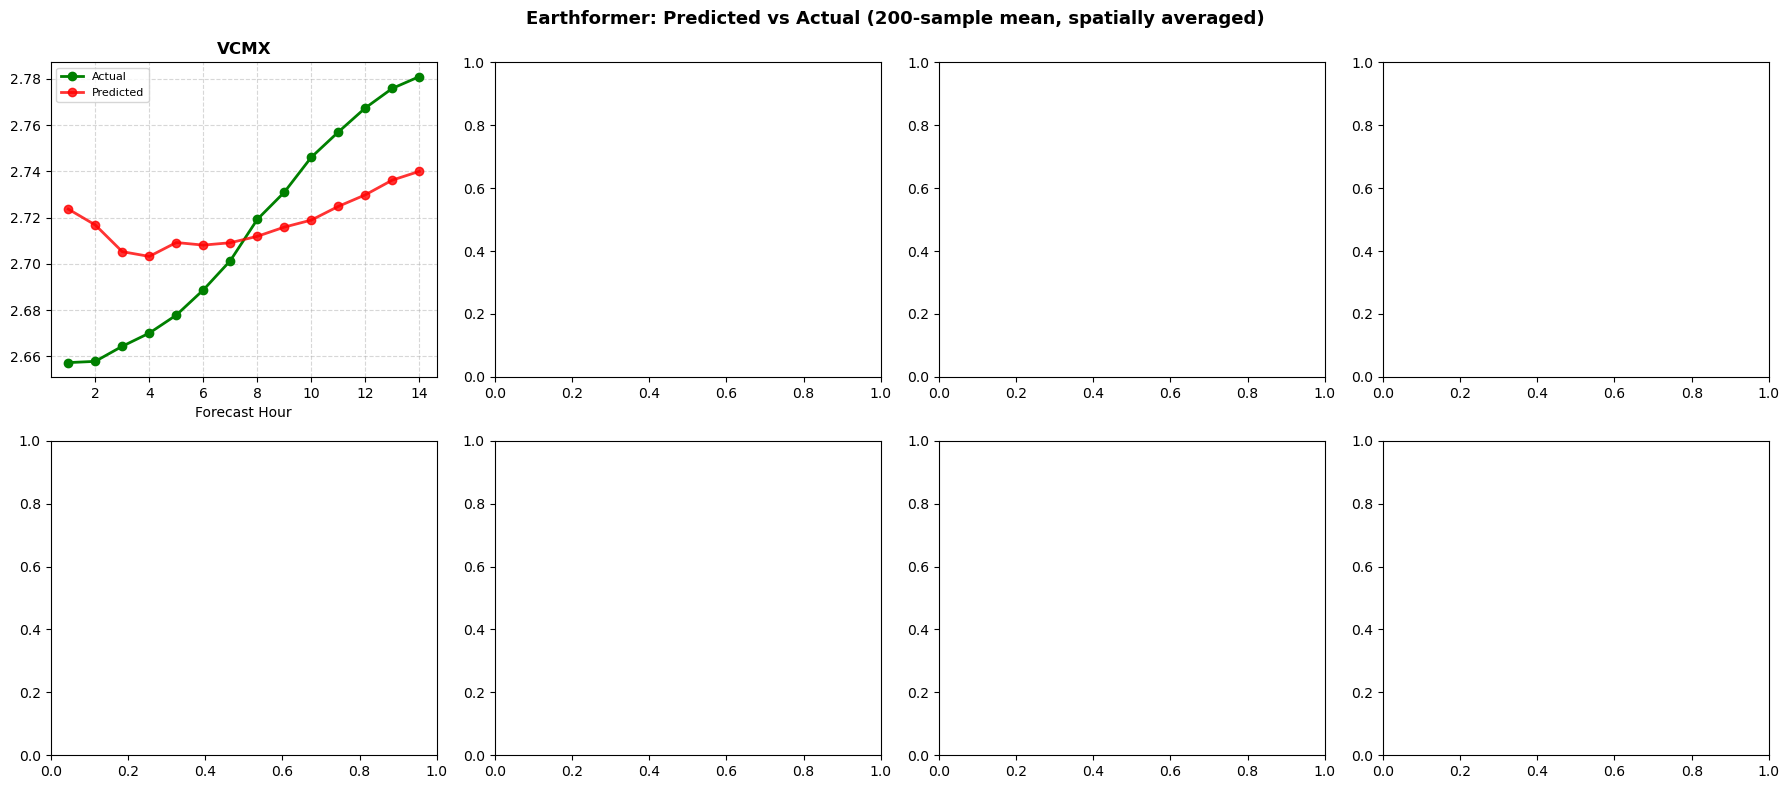

: 

In [ ]:
hours = np.arange(1, FORECAST_HORIZON_HOURS + 1)


hourly_rmse_per_var = {}
hourly_mae_per_var  = {}

for vi, var in enumerate(TARGET_VARS):
    p = preds_orig[:,  :, vi, :, :]   # (N, 4, H, W)
    t = targets_orig[:, :, vi, :, :]  # (N, 4, H, W)
    hourly_rmse_per_var[var] = np.sqrt(np.mean((p - t)**2, axis=(0, 2, 3)))  # (4,)
    hourly_mae_per_var[var]  = np.mean(np.abs(p - t),     axis=(0, 2, 3))   # (4,)

pred_smean   = preds_orig.mean(axis=(3, 4))     # (N, 4, 8)
target_smean = targets_orig.mean(axis=(3, 4))   # (N, 4, 8)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for vi, var in enumerate(TARGET_VARS):
    # Use a random subset of 200 samples for clarity
    idx = np.random.choice(len(pred_smean), min(200, len(pred_smean)), replace=False)
    p_h = pred_smean[idx, :, vi].mean(axis=0)    # (4,) mean over samples
    t_h = target_smean[idx, :, vi].mean(axis=0)  # (4,)
    axes[vi].plot(hours, t_h, 'g-o', label='Actual',    linewidth=2)
    axes[vi].plot(hours, p_h, 'r-o', label='Predicted', linewidth=2, alpha=0.8)
    axes[vi].set_title(var, fontweight='bold')
    axes[vi].set_xlabel('Forecast Hour')
    axes[vi].legend(fontsize=8)
    axes[vi].grid(True, linestyle='--', alpha=0.5)
plt.suptitle('Earthformer: Predicted vs Actual (200-sample mean, spatially averaged)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
